In [ ]:
pip install pybaseball pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 856.7/856.7 kB 12.5 MB/s eta 0:00:00


In [ ]:
from pybaseball import statcast
import pandas as pd

# Pull data (e.g., entire 2024 season – can take a few minutes)
data = statcast(start_dt="2024-03-30", end_dt="2024-10-01")

# Save to CSV (optional)
data.to_csv("statcast_2024.csv", index=False)

This is a large query, it may take a moment to complete


/usr/local/lib/python3.11/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
  0%|          | 0/186 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_co

In [ ]:
# Keep only rows with known pitch type
df = data[data['pitch_type'].notna() & data['zone'].notna()]

# Drop irrelevant columns for now
df = df[['pitch_number','pitch_type', 'balls', 'strikes', 'inning', 'outs_when_up',
         'stand', 'p_throws', 'zone', 'type', 'estimated_ba_using_speedangle', 'on_1b', 'on_2b', 'on_3b']]

# Convert base runner columns to binary
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)

# One-hot encode categorical vars
df = pd.get_dummies(df, columns=['stand', 'p_throws'], drop_first=True)

/tmp/ipython-input-4-1731608554.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)


In [ ]:
df = pd.read_csv('statcast_2023.csv')

cols = ['pitch_number', 'pitch_type', 'balls', 'strikes', 'inning', 'outs_when_up',
        'stand', 'p_throws', 'zone', 'type', 'estimated_ba_using_speedangle',
        'on_1b', 'on_2b', 'on_3b']
df = df[cols]

# Drop rows with missing target values
df = df.loc[df['pitch_type'].notna() & df['zone'].notna()]

# Convert runner columns to binary: 1 if runner present, else 0
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['stand', 'p_throws', 'type'], drop_first=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
le_zone = LabelEncoder()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

y_type = le_type.fit_transform(df['pitch_type'])
y_zone = le_zone.fit_transform(df['zone'])

# Combine into multi-output target matrix
import numpy as np

X = df.drop(columns=['pitch_type', 'zone'])
Y = np.column_stack([y_type, y_zone])


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=y_type, random_state=42)

# Wrap a base estimator
base_model = RandomForestClassifier(n_estimators=100, random_state=42)
multi_model = MultiOutputClassifier(base_model)

# Train
multi_model.fit(X_train, Y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [ ]:
from sklearn.metrics import classification_report

Y_pred = multi_model.predict(X_test)

print("Pitch Type Report:")
print(classification_report(Y_test[:, 0], Y_pred[:, 0], target_names=le_type.classes_))

print("Zone Report:")
print(classification_report(Y_test[:, 1], Y_pred[:, 1], target_names=[str(c) for c in le_zone.classes_]))


Pitch Type Report:
              precision    recall  f1-score   support

          CH       0.19      0.10      0.13     19477
          CS       0.00      0.00      0.00        17
          CU       0.07      0.02      0.03     11894
          EP       0.03      0.01      0.01       137
          FA       0.00      0.00      0.00       281
          FC       0.08      0.02      0.03     14197
          FF       0.34      0.71      0.46     57565
          FO       0.00      0.00      0.00       194
          FS       0.05      0.01      0.02      4006
          KC       0.03      0.01      0.01      3693
          KN       0.00      0.00      0.00        48
          PO       0.00      0.00      0.00        11
          SC       0.00      0.00      0.00        18
          SI       0.23      0.13      0.17     27800
          SL       0.21      0.16      0.18     29163
          ST       0.09      0.02      0.04     10202
          SV       0.01      0.00      0.00       715

    acc

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Version 2


In [ ]:
df = pd.read_csv('statcast_2023.csv')

relevant_cols = ['pitcher', 'pitch_type', 'zone', 'balls', 'strikes', 'inning', 'outs_when_up',
                 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'pitch_number',
                 'estimated_woba_using_speedangle', 'type']
df = df[relevant_cols]

# Drop rows with missing targets or outcome metrics
df.dropna(subset=['pitch_type', 'zone', 'estimated_woba_using_speedangle', 'type'], inplace=True)

In [ ]:
# Base runners to binary
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)

# One-hot encode handedness and pitch outcome
df = pd.get_dummies(df, columns=['stand', 'p_throws', 'type'], drop_first=True)

# Grouping columns (game context)
outcome_cols = [col for col in df.columns if col.startswith('type_')]
group_cols = ['balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b',
              'stand_R', 'p_throws_R'] + outcome_cols


In [ ]:
woba_grouped = df.groupby(group_cols + ['pitch_type', 'zone'])['estimated_woba_using_speedangle'].mean().reset_index()
best_pitch_zone = woba_grouped.sort_values('estimated_woba_using_speedangle')\
                                 .groupby(group_cols).first().reset_index()

# Join best (pitch_type, zone) back as labels
df = df.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))


In [ ]:
le_pitch = LabelEncoder()
le_zone = LabelEncoder()

df['pitch_encoded'] = le_pitch.fit_transform(df['pitch_type_optimal'])
df['zone_encoded'] = le_zone.fit_transform(df['zone_optimal'])

# Features and targets
feature_cols = group_cols + ['pitch_number']
X = df[feature_cols]
Y = df[['pitch_encoded', 'zone_encoded']]

/tmp/ipython-input-56-2971456737.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced = combined.groupby('pitch_encoded', group_keys=False).apply(lambda x: x.sample(min(len(x), min_size)))


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)

base_model = RandomForestClassifier(n_estimators=100, random_state=42)
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, Y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=15,
                                                       min_samples_split=4,
                                                       n_estimators=300,
                                                       random_state=42))

In [ ]:
scenario = pd.DataFrame([{
    'balls': 2,
    'strikes': 1,
    'outs_when_up': 1,
    'on_1b': 1,
    'on_2b': 0,
    'on_3b': 0,
    'stand_R': 1,
    'p_throws_R': 0,
    'pitch_number': 4,
    'type_called_strike': 1,
    'type_ball': 0,
    'type_swinging_strike': 0,
    'type_in_play': 0
}])

for col in X.columns:
    if col not in scenario.columns:
        scenario[col] = 0
scenario = scenario[X.columns]

# Predict with probabilities
pitch_probs = multi_model.estimators_[0].predict_proba(scenario)[0]
zone_probs = multi_model.estimators_[1].predict_proba(scenario)[0]

best_pitch_id = np.argmax(pitch_probs)
pitch_conf = pitch_probs[best_pitch_id]

best_zone_id = np.argmax(zone_probs)
zone_conf = zone_probs[best_zone_id]

pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]
pred_zone = le_zone.inverse_transform([best_zone_id])[0]

print(f"Suggested Pitch: {pred_pitch} (confidence: {pitch_conf:.2f})")
print(f"Suggested Zone: {pred_zone} (confidence: {zone_conf:.2f})")

Suggested Pitch: SL (confidence: 0.34)
Suggested Zone: 13.0 (confidence: 0.45)


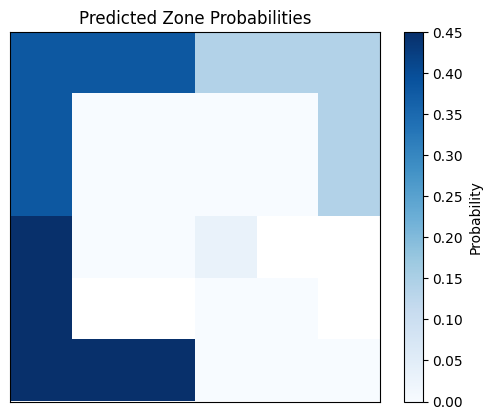

In [ ]:
import matplotlib.pyplot as plt

# Updated 6x5 zone layout
zone_map = np.full((6, 6), np.nan)
zone_indices = {
    11: [(0,0), (0,1), (0,2), (1,0), (2,0)],
    12: [(0,3), (0,4), (0,5),(1,5), (2,5)],
     1: [(1,1)],  2: [(1,2), (1,3)],  3: [(1,4)],
     4: [(2,1)],  5: [(2,2), (2,3)],  6: [(2,4)],
     7: [(3,0)],  8: [(3,1), (3,2)],  9: [(3,3)],
    13: [(3,0), (4,0), (5,0), (5,1), (5,2)],
    14: [(4,3), (4,4), (5,3), (5,4), (5,5)]
}

for i, z in enumerate(le_zone.classes_):
    if z in zone_indices:
        for x, y in zone_indices[z]:
            zone_map[x, y] = zone_probs[i]

plt.imshow(zone_map, cmap='Blues', interpolation='nearest')
plt.title('Predicted Zone Probabilities')
plt.colorbar(label='Probability')
plt.xticks([])
plt.yticks([])
plt.show()



# Version 3


In [ ]:
import pandas as pd
import numpy as np
from pybaseball import statcast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('statcast_2021-2023.csv')

relevant_cols = ['pitcher', 'pitch_type', 'zone', 'balls', 'strikes', 'inning', 'outs_when_up',
                 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'pitch_number',
                 'estimated_woba_using_speedangle', 'type']
df = df[relevant_cols]

# Drop rows with missing targets or outcome metrics
df.dropna(subset=['pitch_type', 'zone', 'estimated_woba_using_speedangle', 'type'], inplace=True)

In [ ]:
# Base runners to binary
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)

# One-hot encode handedness and pitch outcome
df = pd.get_dummies(df, columns=['stand', 'p_throws', 'type'], drop_first=True)

# Grouping columns (game context)
outcome_cols = [col for col in df.columns if col.startswith('type_')]
group_cols = ['balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b',
              'stand_R', 'p_throws_R'] + outcome_cols


In [ ]:
# Define strike-like outcomes
strike_types = ['type_called_strike', 'type_swinging_strike', 'type_foul']

for col in strike_types:
    if col not in df.columns:
        df[col] = 0

# Compute a strike score per group
df['strike_score'] = df[strike_types].sum(axis=1)

# Add penalty for all balls, with extra weight when there are already 3 balls
if 'type_ball' not in df.columns:
    df['type_ball'] = 0


# Add penalty for balls when the count is already 3 balls
df['ball_penalty'] = 0.25 * df.get('type_ball', 0) + 0.50 * ((df['balls'] == 3) & (df.get('type_ball', 0) == 1))

agg = df.groupby(group_cols + ['pitch_type', 'zone'])\
       .agg({
           'estimated_woba_using_speedangle': 'mean',
           'strike_score': 'mean',
           'ball_penalty': 'mean'
       })\
       .reset_index()

agg['combined_score'] = 0.7 * (1 - agg['strike_score']) + 0.3 * agg['estimated_woba_using_speedangle'] + agg['ball_penalty']

# Choose pitch+zone combo with lowest combined score
best_pitch_zone = agg.sort_values('combined_score')\
                  .groupby(group_cols).first().reset_index()

# Join best (pitch_type, zone) back as labels
df = df.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))

In [ ]:
le_pitch = LabelEncoder()
le_zone = LabelEncoder()

df['pitch_encoded'] = le_pitch.fit_transform(df['pitch_type_optimal'])
df['zone_encoded'] = le_zone.fit_transform(df['zone_optimal'])

# Features and targets
feature_cols = group_cols + ['pitch_number']
X = df[feature_cols]
Y = df[['pitch_encoded', 'zone_encoded']]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y['pitch_encoded'], random_state=42)

# Train base model with increased capacity
base_model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=4, random_state=42)
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, Y_train)

# Evaluate
from sklearn.metrics import classification_report

Y_pred = multi_model.predict(X_test)
print("Pitch Type Report:")
print(classification_report(Y_test['pitch_encoded'], Y_pred[:, 0], target_names=le_pitch.classes_))

print("Zone Report:")
print(classification_report(Y_test['zone_encoded'], Y_pred[:, 1], target_names=[str(z) for z in le_zone.classes_]))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)

base_model = RandomForestClassifier(n_estimators=100, random_state=42)
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, Y_train)

Pitch Type Report:
              precision    recall  f1-score   support

          CH       1.00      1.00      1.00     11884
          CS       1.00      1.00      1.00      2132
          CU       1.00      1.00      1.00      7271
          EP       1.00      1.00      1.00      3953
          FA       1.00      1.00      1.00      8467
          FC       1.00      1.00      1.00      9034
          FF       1.00      1.00      1.00      5088
          FO       1.00      1.00      1.00       728
          FS       1.00      1.00      1.00      6226
          KC       1.00      1.00      1.00      6938
          KN       1.00      1.00      1.00      2296
          SI       1.00      1.00      1.00      6627
          SL       1.00      1.00      1.00     11077
          ST       1.00      1.00      1.00     18316
          SV       1.00      1.00      1.00      9699

    accuracy                           1.00    109736
   macro avg       1.00      1.00      1.00    109736
weighte

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

DATA LEAKAGE :(

In [ ]:
scenario = pd.DataFrame([{
    'balls': 3,
    'strikes': 1,
    'outs_when_up': 0,
    'on_1b': 0,
    'on_2b': 1,
    'on_3b': 1,
    'stand_R': 1,
    'p_throws_R': 0,
    'pitch_number': 4,
    'type_called_strike': 1,
    'type_ball': 0,
    'type_swinging_strike': 0,
    'type_in_play': 0
}])

for col in X.columns:
    if col not in scenario.columns:
        scenario[col] = 0
scenario = scenario[X.columns]

# Predict with probabilities
pitch_probs = multi_model.estimators_[0].predict_proba(scenario)[0]
zone_probs = multi_model.estimators_[1].predict_proba(scenario)[0]

best_pitch_id = np.argmax(pitch_probs)
pitch_conf = pitch_probs[best_pitch_id]

best_zone_id = np.argmax(zone_probs)
zone_conf = zone_probs[best_zone_id]

pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]
pred_zone = le_zone.inverse_transform([best_zone_id])[0]

print(f"Suggested Pitch: {pred_pitch} (confidence: {pitch_conf:.2f})")
print(f"Suggested Zone: {pred_zone} (confidence: {zone_conf:.2f})")

Suggested Pitch: FF (confidence: 0.76)
Suggested Zone: 11.0 (confidence: 0.46)


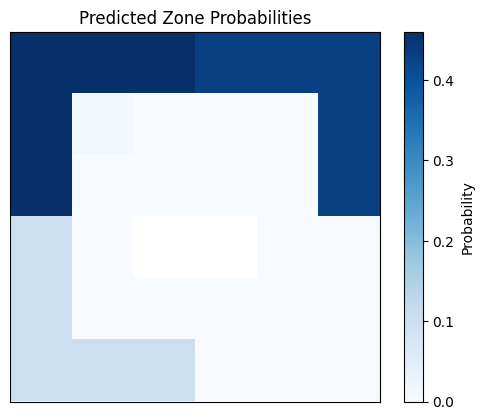

In [ ]:
import matplotlib.pyplot as plt

# Updated 6x5 zone layout
zone_map = np.full((6, 6), np.nan)
zone_indices = {
    11: [(0,0), (0,1), (0,2), (1,0), (2,0)],
    12: [(0,3), (0,4), (0,5),(1,5), (2,5)],
     1: [(1,1)],  2: [(1,2), (1,3)],  3: [(1,4)],
     4: [(2,1), (3,1)],  5: [(2,2), (2,3)],  6: [(2,4), (3,4)],
     7: [(4,1)],  8: [(4,2), (4,3)],  9: [(4,4)],
    13: [(3,0), (4,0), (5,0), (5,1), (5,2)],
    14: [(3,5), (4,5), (5,3), (5,4), (5,5)]
}

for i, z in enumerate(le_zone.classes_):
    if z in zone_indices:
        for x, y in zone_indices[z]:
            zone_map[x, y] = zone_probs[i]

plt.imshow(zone_map, cmap='Blues', interpolation='nearest')
plt.title('Predicted Zone Probabilities')
plt.colorbar(label='Probability')
plt.xticks([])
plt.yticks([])
plt.show()



## Version 4

In [ ]:
import pandas as pd
import numpy as np
from pybaseball import statcast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt

# -------------------------
# 1. Load and Filter Data
# -------------------------

df = pd.read_csv('statcast_2023.csv')

relevant_cols = ['pitcher', 'pitch_type', 'zone', 'balls', 'strikes', 'inning', 'outs_when_up',
                 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'pitch_number',
                 'estimated_woba_using_speedangle', 'description', 'events']
df = df[relevant_cols]

# Define new strike score from description
strike_descriptions = [
    'called_strike', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'foul'
]
df['strike_score'] = df['description'].isin(strike_descriptions).astype(int)

# Ball penalty
df['ball_penalty'] = (df['description'] == 'ball').astype(int) * 0.1

# Outcome penalty/reward from 'event'
out_events = ['field_out', 'force_out', 'double_play', 'strikeout']
hit_events = ['single', 'double', 'triple', 'home_run']
df['out_reward'] = df['events'].isin(out_events).astype(int)
df['hit_penalty'] = df['events'].isin(hit_events).astype(int) * 0.2

# Convert base runner columns to binary
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)

# One-hot encode categorical vars
df = pd.get_dummies(df, columns=['stand', 'p_throws'], drop_first=True)


# -------------------------
# 2. Derive Optimal Pitch/Zone Labels (Before Splitting)
# -------------------------
group_cols = ['balls', 'strikes', 'inning', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b',
              'stand_R', 'p_throws_R']


agg = df.groupby(group_cols + ['pitch_type', 'zone']).agg({
    'estimated_woba_using_speedangle': 'mean',
    'strike_score': 'mean',
    'ball_penalty': 'mean',
    'out_reward': 'mean',
    'hit_penalty': 'mean'
}).reset_index()
agg['combined_score'] = 0.5 * (1 - agg['strike_score']) + 0.3 * agg['estimated_woba_using_speedangle'] + \
                        0.1 * agg['hit_penalty'] + 0.1 * agg['ball_penalty'] - 0.1 * agg['out_reward']
best_pitch_zone = agg.sort_values('combined_score').groupby(group_cols).first().reset_index()
df = df.drop(columns=['strike_score', 'ball_penalty', 'hit_penalty', 'out_reward'], errors='ignore')
df = df.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))

In [ ]:
# -------------------------
# 3. Split Data (After Label Creation)
# -------------------------
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# -------------------------
# 4. Encode Features and Labels
# -------------------------
le_pitch = LabelEncoder()
le_zone = LabelEncoder()

for df_part in [df_train, df_test]:
    df_part['pitch_encoded'] = le_pitch.fit_transform(df_part['pitch_type_optimal'])
    df_part['zone_encoded'] = le_zone.fit_transform(df_part['zone_optimal'])

feature_cols = group_cols + ['pitch_number']
X_train = df_train[feature_cols]
Y_train = df_train[['pitch_encoded', 'zone_encoded']]
X_test = df_test[feature_cols]
Y_test = df_test[['pitch_encoded', 'zone_encoded']]

In [ ]:
from sklearn.metrics import classification_report

# -------------------------
# 5. Train Model
# -------------------------
base_model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=4, random_state=42)
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, Y_train)

# -------------------------
# 6. Evaluate Model
# -------------------------
Y_pred = multi_model.predict(X_test)
print("Pitch Type Report:")
print(classification_report(Y_test['pitch_encoded'], Y_pred[:, 0], target_names=le_pitch.classes_))

print("\nZone Report:")
print(classification_report(Y_test['zone_encoded'], Y_pred[:, 1], target_names=[str(z) for z in le_zone.classes_]))

Pitch Type Report:
              precision    recall  f1-score   support

          CH       1.00      1.00      1.00     12898
          CU       1.00      1.00      1.00      9725
          EP       0.98      1.00      0.99        41
          FA       0.97      0.98      0.97        92
          FC       1.00      1.00      1.00     13484
          FF       1.00      1.00      1.00     45480
          FO       1.00      1.00      1.00       830
          FS       1.00      0.99      1.00      2801
          KC       0.99      0.99      0.99      2242
          KN       1.00      1.00      1.00       142
          SC       0.98      1.00      0.99       130
          SI       0.99      1.00      0.99     19995
          SL       1.00      1.00      1.00     24354
          ST       1.00      1.00      1.00     10018
          SV       1.00      1.00      1.00      1357

    accuracy                           1.00    143589
   macro avg       0.99      1.00      0.99    143589
weighte

In [ ]:
# -------------------------
# 7. Predict a Scenario (with Arsenal Masking)
# -------------------------
scenario = pd.DataFrame([{
    'balls': 3,
    'strikes': 1,
    'outs_when_up': 0,
    'on_1b': 1,
    'on_2b': 1,
    'on_3b': 1,
    'stand_R': 1,
    'p_throws_R': 0,
    'pitch_number': 4,
    'type_called_strike': 0,
    'type_ball': 1,
    'type_swinging_strike': 0,
    'type_in_play': 0
}])

for col in X_train.columns:
    if col not in scenario.columns:
        scenario[col] = 0
scenario = scenario[X_train.columns]

pitch_probs = multi_model.estimators_[0].predict_proba(scenario)[0]
zone_probs = multi_model.estimators_[1].predict_proba(scenario)[0]

best_pitch_id = np.argmax(pitch_probs)
pitch_conf = pitch_probs[best_pitch_id]
best_zone_id = np.argmax(zone_probs)
zone_conf = zone_probs[best_zone_id]

pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]
pred_zone = le_zone.inverse_transform([best_zone_id])[0]

print(f"Suggested Pitch: {pred_pitch} (confidence: {pitch_conf:.2f})")
print(f"Suggested Zone: {pred_zone} (confidence: {zone_conf:.2f})")


# Mask predictions based on pitcher's arsenal
pitcher_arsenal = ['FF', 'SL', 'CH', 'CU']  # example arsenal
allowed_indices = [i for i, pitch in enumerate(le_pitch.classes_) if pitch in pitcher_arsenal]

# Set probabilities of disallowed pitches to zero
masked_pitch_probs = np.zeros_like(pitch_probs)
masked_pitch_probs[allowed_indices] = pitch_probs[allowed_indices]

best_pitch_id = np.argmax(masked_pitch_probs)
pitch_conf = masked_pitch_probs[best_pitch_id]
pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]

print(f"Suggested Pitch (with arsenal masking): {pred_pitch} (confidence: {pitch_conf:.2f})")

Suggested Pitch: FF (confidence: 0.49)
Suggested Zone: 12.0 (confidence: 0.34)
Suggested Pitch (with arsenal masking): FF (confidence: 0.49)


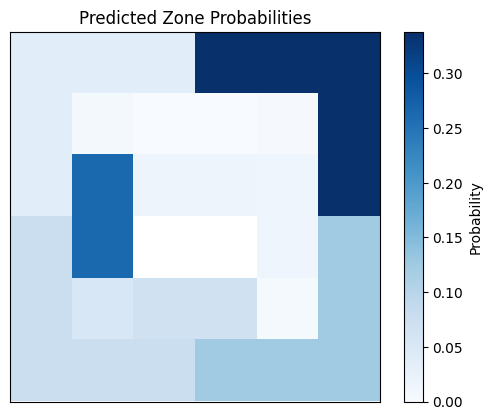

In [ ]:

# Updated 6x5 zone layout
zone_map = np.full((6, 6), np.nan)
zone_indices = {
    11: [(0,0), (0,1), (0,2), (1,0), (2,0)],
    12: [(0,3), (0,4), (0,5),(1,5), (2,5)],
     1: [(1,1)],  2: [(1,2), (1,3)],  3: [(1,4)],
     4: [(2,1), (3,1)],  5: [(2,2), (2,3)],  6: [(2,4), (3,4)],
     7: [(4,1)],  8: [(4,2), (4,3)],  9: [(4,4)],
    13: [(3,0), (4,0), (5,0), (5,1), (5,2)],
    14: [(3,5), (4,5), (5,3), (5,4), (5,5)]
}

for i, z in enumerate(le_zone.classes_):
    if z in zone_indices:
        for x, y in zone_indices[z]:
            zone_map[x, y] = zone_probs[i]

plt.imshow(zone_map, cmap='Blues', interpolation='nearest')
plt.title('Predicted Zone Probabilities')
plt.colorbar(label='Probability')
plt.xticks([])
plt.yticks([])
plt.show()

# Version 5

In [ ]:
import pandas as pd
import numpy as np
from pybaseball import statcast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt

# -------------------------
# 1. Load and Filter Data
# -------------------------

df = pd.read_csv('statcast_2023.csv')

relevant_cols = ['pitcher', 'pitch_type', 'zone', 'balls', 'strikes', 'inning', 'outs_when_up',
                 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'pitch_number',
                 'estimated_woba_using_speedangle', 'description', 'events']
df = df[relevant_cols]

df.dropna(subset=['pitch_type', 'zone', 'estimated_woba_using_speedangle', 'description', 'events'], inplace=True)
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)
df = pd.get_dummies(df, columns=['stand', 'p_throws'], drop_first=True)

# Define new strike score from description
strike_descriptions = [
    'called_strike', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'foul'
]
df['strike_score'] = df['description'].isin(strike_descriptions).astype(int)

# Ball penalty
df['ball_penalty'] = (df['description'] == 'ball').astype(int) * 0.1

# Outcome penalty/reward from 'event'
out_events = ['field_out', 'force_out', 'double_play', 'strikeout']
hit_events = ['single', 'double', 'triple', 'home_run']
df['out_reward'] = df['events'].isin(out_events).astype(int)
df['hit_penalty'] = df['events'].isin(hit_events).astype(int) * 0.2

In [ ]:
# -------------------------
# 2. Split Data First (to Avoid Label Leakage)
# -------------------------
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# -------------------------
# 3. Derive Optimal Pitch/Zone Labels from Training Data Only
# -------------------------
group_cols = ['balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b',
              'stand_R', 'p_throws_R']

agg = df_train.groupby(group_cols + ['pitch_type', 'zone']).agg({
    'estimated_woba_using_speedangle': 'mean',
    'strike_score': 'mean',
    'ball_penalty': 'mean',
    'out_reward': 'mean',
    'hit_penalty': 'mean'
}).reset_index()
agg['combined_score'] = 0.5 * (1 - agg['strike_score']) + 0.3 * agg['estimated_woba_using_speedangle'] + \
                        0.1 * agg['hit_penalty'] + 0.1 * agg['ball_penalty'] - 0.1 * agg['out_reward']
best_pitch_zone = agg.sort_values('combined_score').groupby(group_cols).first().reset_index()

# Attach optimal labels to both train and test

df_train = df_train.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))
df_test = df_test.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))
# -------------------------
#df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# -------------------------
# 4. Encode Features and Labels
# -------------------------
le_pitch = LabelEncoder()
le_zone = LabelEncoder()

for df_part in [df_train, df_test]:
    df_part['pitch_encoded'] = le_pitch.fit_transform(df_part['pitch_type_optimal'])
    df_part['zone_encoded'] = le_zone.fit_transform(df_part['zone_optimal'])

feature_cols = ['balls', 'strikes', 'pitch_number', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b', 'stand_R', 'p_throws_R']
X_train = df_train[feature_cols]
Y_train = df_train[['pitch_encoded', 'zone_encoded']]
X_test = df_test[feature_cols]
Y_test = df_test[['pitch_encoded', 'zone_encoded']]


In [ ]:
# -------------------------
# 5. Train Model
# -------------------------
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

base_model = HistGradientBoostingClassifier(max_iter=300, max_depth=15, random_state=42)
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, Y_train)

# -------------------------
# 6. Evaluate Model
# -------------------------
Y_pred = multi_model.predict(X_test)
print("Pitch Type Report:")
print(classification_report(Y_test['pitch_encoded'], Y_pred[:, 0], target_names=le_pitch.classes_))

print("\nZone Report:")
print(classification_report(Y_test['zone_encoded'], Y_pred[:, 1], target_names=[str(z) for z in le_zone.classes_]))

Pitch Type Report:
              precision    recall  f1-score   support

          CH       1.00      1.00      1.00      5521
          CU       1.00      1.00      1.00      2578
          EP       1.00      1.00      1.00       110
          FA       1.00      1.00      1.00      1183
          FC       1.00      1.00      1.00      4498
          FF       1.00      1.00      1.00      3071
          FO       1.00      1.00      1.00      1184
          FS       1.00      1.00      1.00      2440
          KC       1.00      1.00      1.00      1167
          KN       1.00      1.00      1.00       784
          SI       1.00      1.00      1.00      3285
          SL       1.00      1.00      1.00      2832
          ST       1.00      1.00      1.00      6524
          SV       1.00      1.00      1.00      1343

    accuracy                           1.00     36520
   macro avg       1.00      1.00      1.00     36520
weighted avg       1.00      1.00      1.00     36520


Zone 

In [ ]:
# -------------------------
# 7. Predict a Scenario (with Arsenal Masking)
# -------------------------
scenario = pd.DataFrame([{
    'balls': 3,
    'strikes': 0,
    'outs_when_up': 0,
    'on_1b': 1,
    'on_2b': 0,
    'on_3b': 0,
    'stand_R': 1,
    'p_throws_R': 0,
    'pitch_number': 3,
    # Strike-related features no longer used
    # These will be dropped automatically if not in training data
}])

for col in X_train.columns:
    if col not in scenario.columns:
        scenario[col] = 0
scenario = scenario[X_train.columns]

pitch_probs = multi_model.estimators_[0].predict_proba(scenario)[0]
zone_probs = multi_model.estimators_[1].predict_proba(scenario)[0]

best_pitch_id = np.argmax(pitch_probs)
pitch_conf = pitch_probs[best_pitch_id]
best_zone_id = np.argmax(zone_probs)
zone_conf = zone_probs[best_zone_id]

pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]
pred_zone = le_zone.inverse_transform([best_zone_id])[0]

print(f"Suggested Pitch: {pred_pitch} (confidence: {pitch_conf:.2f})")
print(f"Suggested Zone: {pred_zone} (confidence: {zone_conf:.2f})")


# Mask predictions based on pitcher's arsenal
pitcher_arsenal = ['FF', 'SL', 'CH', 'CU']  # example arsenal
allowed_indices = [i for i, pitch in enumerate(le_pitch.classes_) if pitch in pitcher_arsenal]

# Set probabilities of disallowed pitches to zero
masked_pitch_probs = np.zeros_like(pitch_probs)
masked_pitch_probs[allowed_indices] = pitch_probs[allowed_indices]

best_pitch_id = np.argmax(masked_pitch_probs)
pitch_conf = masked_pitch_probs[best_pitch_id]
pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]

print(f"Suggested Pitch (with arsenal masking): {pred_pitch} (confidence: {pitch_conf:.2f})")


Suggested Pitch: FF (confidence: 0.52)
Suggested Zone: 5.0 (confidence: 0.88)
Suggested Pitch (with arsenal masking): FF (confidence: 0.52)


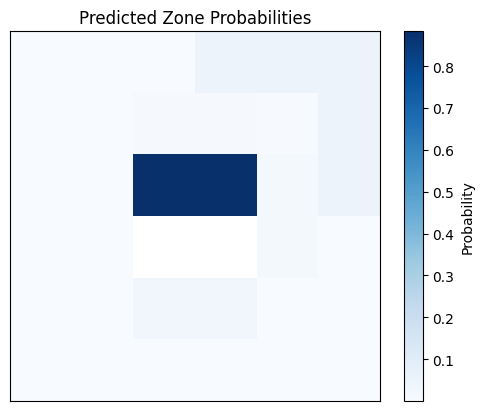

In [ ]:
zone_map = np.full((6, 6), np.nan)
zone_indices = {
    11: [(0,0), (0,1), (0,2), (1,0), (2,0)],
    12: [(0,3), (0,4), (0,5),(1,5), (2,5)],
     1: [(1,1)],  2: [(1,2), (1,3)],  3: [(1,4)],
     4: [(2,1), (3,1)],  5: [(2,2), (2,3)],  6: [(2,4), (3,4)],
     7: [(4,1)],  8: [(4,2), (4,3)],  9: [(4,4)],
    13: [(3,0), (4,0), (5,0), (5,1), (5,2)],
    14: [(3,5), (4,5), (5,3), (5,4), (5,5)]
}

for i, z in enumerate(le_zone.classes_):
    if z in zone_indices:
        for x, y in zone_indices[z]:
            zone_map[x, y] = zone_probs[i]

plt.imshow(zone_map, cmap='Blues', interpolation='nearest')
plt.title('Predicted Zone Probabilities')
plt.colorbar(label='Probability')
plt.xticks([])
plt.yticks([])
plt.show()

# Version 6 - Neural Net

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from pybaseball import statcast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


# -------------------------
# 1. Load and Filter Data
# -------------------------

df = pd.read_csv('statcast_2023.csv')

relevant_cols = ['pitcher', 'pitch_type', 'zone', 'balls', 'strikes', 'inning', 'outs_when_up',
                 'on_1b', 'on_2b', 'on_3b', 'stand', 'p_throws', 'pitch_number',
                 'estimated_woba_using_speedangle', 'description', 'events']
df = df[relevant_cols]
df.dropna(subset=['pitch_type', 'zone', 'estimated_woba_using_speedangle', 'description', 'events'], inplace=True)
df[['on_1b', 'on_2b', 'on_3b']] = df[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)
df = pd.get_dummies(df, columns=['stand', 'p_throws'], drop_first=True)

strike_descriptions = ['called_strike', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'foul']
df['strike_score'] = df['description'].isin(strike_descriptions).astype(int)
df['ball_penalty'] = (df['description'] == 'ball').astype(int) * 0.1

out_events = ['field_out', 'force_out', 'double_play', 'strikeout']
hit_events = ['single', 'double', 'triple', 'home_run']
df['out_reward'] = df['events'].isin(out_events).astype(int)
df['hit_penalty'] = df['events'].isin(hit_events).astype(int) * 0.2

In [ ]:
# -------------------------
# 2. Split Data
# -------------------------
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# -------------------------
# 3. Derive Optimal Labels
# -------------------------
group_cols = ['balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b', 'stand_R', 'p_throws_R']
agg = df_train.groupby(group_cols + ['pitch_type', 'zone']).agg({
    'estimated_woba_using_speedangle': 'mean',
    'strike_score': 'mean',
    'ball_penalty': 'mean',
    'out_reward': 'mean',
    'hit_penalty': 'mean'
}).reset_index()
agg['combined_score'] = 0.5 * (1 - agg['strike_score']) + 0.3 * agg['estimated_woba_using_speedangle'] + \
                        0.1 * agg['hit_penalty'] + 0.1 * agg['ball_penalty'] - 0.1 * agg['out_reward']
best_pitch_zone = agg.sort_values('combined_score').groupby(group_cols).first().reset_index()
df_train = df_train.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))
df_test = df_test.merge(best_pitch_zone, on=group_cols, how='inner', suffixes=('', '_optimal'))

# -------------------------
# 4. Encode Features and Labels
# -------------------------
le_pitch = LabelEncoder()
le_zone = LabelEncoder()
for df_part in [df_train, df_test]:
    df_part['pitch_encoded'] = le_pitch.fit_transform(df_part['pitch_type_optimal'])
    df_part['zone_encoded'] = le_zone.fit_transform(df_part['zone_optimal'])

feature_cols = ['balls', 'strikes', 'pitch_number', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b', 'stand_R', 'p_throws_R']
X_train = df_train[feature_cols]
Y_train = df_train[['pitch_encoded', 'zone_encoded']]
X_test = df_test[feature_cols]
Y_test = df_test[['pitch_encoded', 'zone_encoded']]

In [ ]:
# -------------------------
# 5. Neural Network Model
# -------------------------
n_input = Input(shape=(X_train.shape[1],))
shared = Dense(64, activation='relu')(n_input)
shared = Dense(64, activation='relu')(shared)

pitch_output = Dense(len(le_pitch.classes_), activation='softmax', name='pitch_output')(shared)
zone_output = Dense(len(le_zone.classes_), activation='softmax', name='zone_output')(shared)

nn_model = Model(inputs=n_input, outputs=[pitch_output, zone_output])
nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy', 'accuracy'])
nn_model.fit(X_train.astype('float32').to_numpy(), [Y_train['pitch_encoded'].astype('int32').to_numpy(), Y_train['zone_encoded'].astype('int32').to_numpy()], epochs=10, batch_size=64, verbose=2)


Epoch 1/10
2283/2283 - 6s - 3ms/step - loss: 3.2082 - pitch_output_accuracy: 0.5170 - pitch_output_loss: 1.4609 - zone_output_accuracy: 0.4466 - zone_output_loss: 1.7470
Epoch 2/10
2283/2283 - 6s - 3ms/step - loss: 1.7427 - pitch_output_accuracy: 0.7690 - pitch_output_loss: 0.7666 - zone_output_accuracy: 0.7293 - zone_output_loss: 0.9760
Epoch 3/10
2283/2283 - 5s - 2ms/step - loss: 1.1826 - pitch_output_accuracy: 0.8524 - pitch_output_loss: 0.5202 - zone_output_accuracy: 0.8201 - zone_output_loss: 0.6623
Epoch 4/10
2283/2283 - 6s - 3ms/step - loss: 0.9045 - pitch_output_accuracy: 0.8873 - pitch_output_loss: 0.3962 - zone_output_accuracy: 0.8643 - zone_output_loss: 0.5082
Epoch 5/10
2283/2283 - 4s - 2ms/step - loss: 0.7338 - pitch_output_accuracy: 0.9072 - pitch_output_loss: 0.3209 - zone_output_accuracy: 0.8910 - zone_output_loss: 0.4127
Epoch 6/10
2283/2283 - 5s - 2ms/step - loss: 0.6080 - pitch_output_accuracy: 0.9238 - pitch_output_loss: 0.2657 - zone_output_accuracy: 0.9113 - zone_


Fold 1:
913/913 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Pitch Type Confusion Matrix:


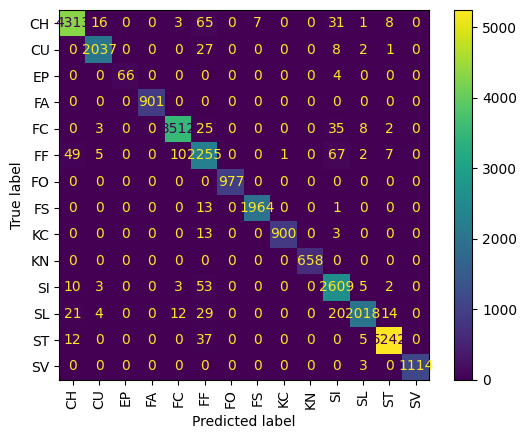

Zone Confusion Matrix:


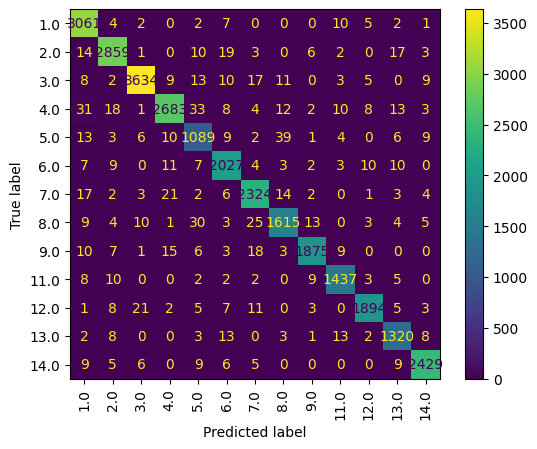


Fold 2:
913/913 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Pitch Type Confusion Matrix:


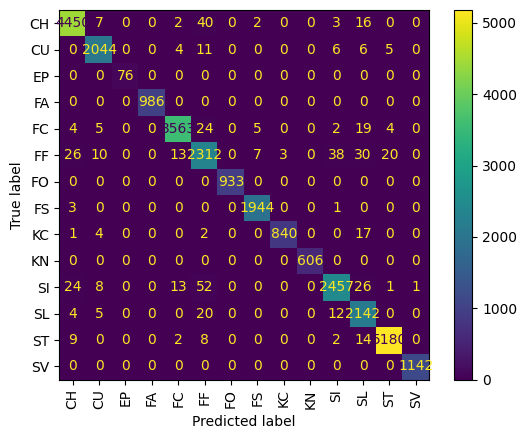

Zone Confusion Matrix:


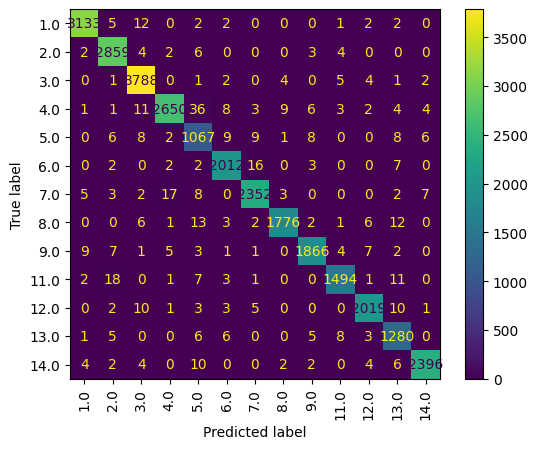


Fold 3:
913/913 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Pitch Type Confusion Matrix:


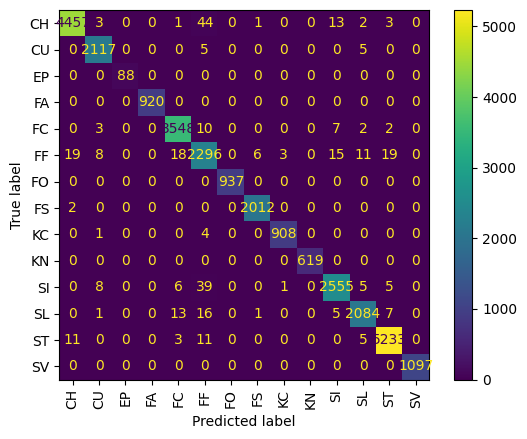

Zone Confusion Matrix:


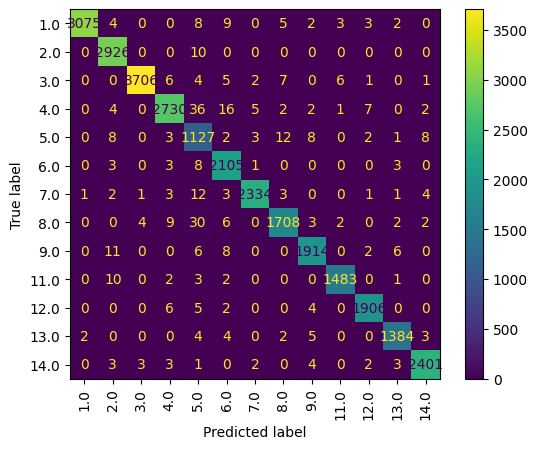


Fold 4:
913/913 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Pitch Type Confusion Matrix:


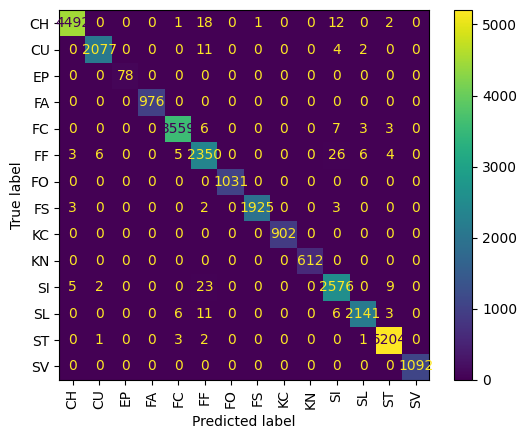

Zone Confusion Matrix:


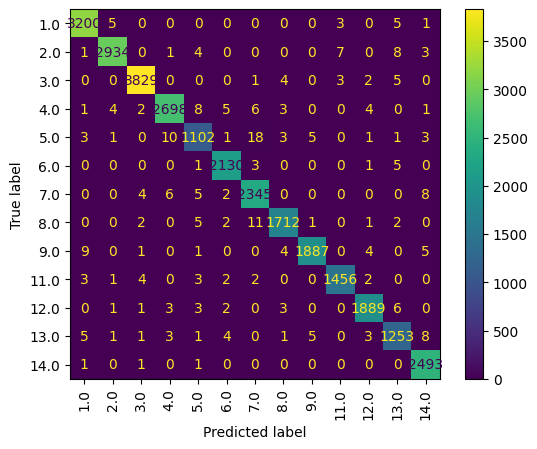


Fold 5:
913/913 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Pitch Type Confusion Matrix:


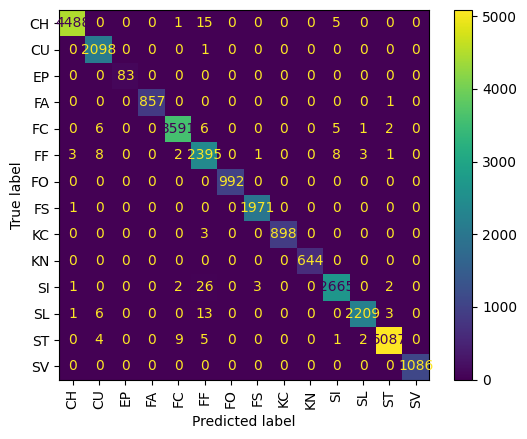

Zone Confusion Matrix:


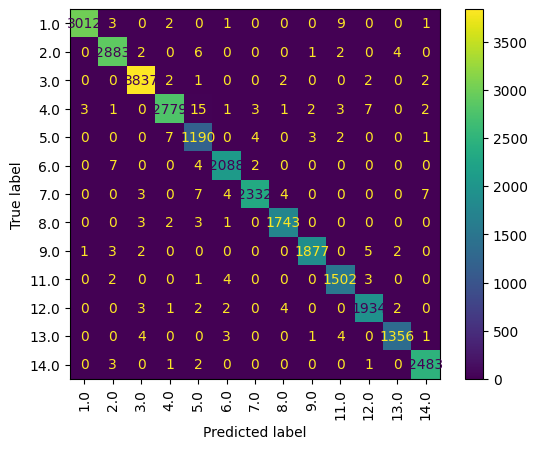

In [ ]:
# -------------------------
# 6. K-Fold CV and Confusion Matrices (NN)
# -------------------------
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

kf = KFold(n_splits=5)
fold = 1
for train_index, val_index in kf.split(X_train):
    print(f"\nFold {fold}:")
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    Y_tr = [Y_train['pitch_encoded'].iloc[train_index], Y_train['zone_encoded'].iloc[train_index]]
    Y_val = [Y_train['pitch_encoded'].iloc[val_index], Y_train['zone_encoded'].iloc[val_index]]

    nn_model.fit(X_tr.astype('float32').to_numpy(), [y.to_numpy() for y in Y_tr], epochs=5, batch_size=64, verbose=0)

    y_pred_nn = nn_model.predict(X_val.astype('float32').to_numpy())
    y_pitch_pred = np.argmax(y_pred_nn[0], axis=1)
    y_zone_pred = np.argmax(y_pred_nn[1], axis=1)

    print("Pitch Type Confusion Matrix:")
    ConfusionMatrixDisplay(confusion_matrix(Y_val[0], y_pitch_pred), display_labels=le_pitch.classes_).plot(xticks_rotation=90)
    plt.show()

    print("Zone Confusion Matrix:")
    ConfusionMatrixDisplay(confusion_matrix(Y_val[1], y_zone_pred), display_labels=le_zone.classes_).plot(xticks_rotation=90)
    plt.show()

    fold += 1


In [ ]:
# -------------------------
# 6. Predict a Scenario (Neural Net with Arsenal Masking)
# -------------------------
scenario = pd.DataFrame([
    {'balls': 3, 'strikes': 2, 'outs_when_up': 1, 'on_1b': 0, 'on_2b': 0, 'on_3b': 0, 'stand_R': 1, 'p_throws_R': 0, 'pitch_number': 5
}])

for col in X_train.columns:
    if col not in scenario.columns:
        scenario[col] = 0
scenario = scenario[X_train.columns]

pitch_probs, zone_probs = nn_model.predict(scenario)
pitch_probs = pitch_probs[0]
zone_probs = zone_probs[0]

all_pitch_preds = pd.DataFrame({
    'pitch': le_pitch.inverse_transform(np.arange(len(pitch_probs))),
    'probability': pitch_probs
}).sort_values(by='probability', ascending=False)
print("\nAll pitch predictions:")
print(all_pitch_preds)

best_pitch_id = np.argmax(pitch_probs)
pitch_conf = pitch_probs[best_pitch_id]
best_zone_id = np.argmax(zone_probs)
zone_conf = zone_probs[best_zone_id]

pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]
pred_zone = le_zone.inverse_transform([best_zone_id])[0]

print(f"Suggested Pitch: {pred_pitch} (confidence: {pitch_conf:.2f})")
print(f"Suggested Zone: {pred_zone} (confidence: {zone_conf:.2f})")

# Mask predictions based on pitcher's arsenal
pitcher_arsenal = ['FF', 'SL', 'CH', 'CU', 'SI']
allowed_indices = [i for i, pitch in enumerate(le_pitch.classes_) if pitch in pitcher_arsenal]

masked_pitch_probs = np.zeros_like(pitch_probs)
masked_pitch_probs[allowed_indices] = pitch_probs[allowed_indices]

best_pitch_id = np.argmax(masked_pitch_probs)
pitch_conf = masked_pitch_probs[best_pitch_id]
pred_pitch = le_pitch.inverse_transform([best_pitch_id])[0]

print(f"Suggested Pitch (with arsenal masking): {pred_pitch} (confidence: {pitch_conf:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

All pitch predictions:
   pitch   probability
11    SL  9.999763e-01
13    SV  2.367806e-05
1     CU  4.626934e-10
0     CH  3.023124e-10
10    SI  1.225935e-11
12    ST  1.134526e-18
4     FC  5.479279e-21
7     FS  1.040266e-24
5     FF  1.561519e-29
3     FA  0.000000e+00
2     EP  0.000000e+00
9     KN  0.000000e+00
6     FO  0.000000e+00
8     KC  0.000000e+00
Suggested Pitch: SL (confidence: 1.00)
Suggested Zone: 3.0 (confidence: 1.00)
Suggested Pitch (with arsenal masking): SL (confidence: 1.00)


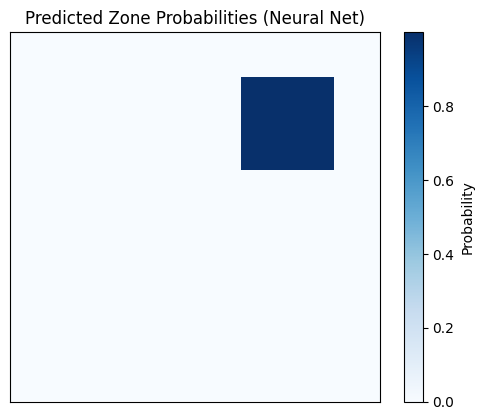

In [ ]:
# -------------------------
# 7. Visualize Zone Probabilities (Neural Net)
# -------------------------
zone_map = np.full((8, 8), np.nan)
zone_indices = {
    11: [(0,0), (0,1), (0,2), (0,3), (1,0), (2,0), (3,0)],
    12: [(0,4), (0,5), (0,6), (0,7), (1,7), (2,7), (3,7)],
     1: [(1,1), (1,2), (2,1), (2,2)],  2: [(1,3), (1,4), (2,3), (2,4)],  3: [(1,5), (1,6), (2,5), (2,6)],
     4: [(3,1), (3,2), (4,1), (4,2)],  5: [(3,3), (3,4), (4,3), (4,4)],  6: [(3,5), (3,6), (4,5), (4,6)],
     7: [(5,1), (5,2), (6,1), (6,2)],  8: [(5,3), (5,4), (6,3), (6,4)],  9: [(5,5), (5,6), (6,5), (6,6)],
    13: [(7,0), (7,1), (7,2), (7,3), (4,0), (5,0), (6,0)],
    14: [(7,4), (7,5), (7,6), (7,7), (6,7), (5,7), (4,7)]
}

for i, z in enumerate(le_zone.classes_):
    if z in zone_indices:
        for x, y in zone_indices[z]:
            zone_map[x, y] = zone_probs[i]

plt.imshow(zone_map, cmap='Blues', interpolation='nearest')
plt.title('Predicted Zone Probabilities (Neural Net)')
plt.colorbar(label='Probability')
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
# -------------------------
# 7. Evaluate Model on 2024 Data
# -------------------------
df_2024 = pd.read_csv('statcast_2024.csv')
df_2024 = df_2024[relevant_cols]
df_2024.dropna(subset=['pitch_type', 'zone', 'estimated_woba_using_speedangle', 'description', 'events'], inplace=True)
df_2024[['on_1b', 'on_2b', 'on_3b']] = df_2024[['on_1b', 'on_2b', 'on_3b']].notna().astype(int)
df_2024 = pd.get_dummies(df_2024, columns=['stand', 'p_throws'], drop_first=True)

for col in ['stand_R', 'p_throws_R']:
    if col not in df_2024.columns:
        df_2024[col] = 0

# Recalculate outcome scores
strike_descriptions = ['called_strike', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'foul']
df_2024['strike_score'] = df_2024['description'].isin(strike_descriptions).astype(int)
df_2024['ball_penalty'] = (df_2024['description'] == 'ball').astype(int) * 0.1
df_2024['out_reward'] = df_2024['events'].isin(out_events).astype(int)
df_2024['hit_penalty'] = df_2024['events'].isin(hit_events).astype(int) * 0.2

X_2024 = df_2024[feature_cols].astype('float32')
y_preds = nn_model.predict(X_2024.to_numpy())
y_pitch_pred = np.argmax(y_preds[0], axis=1)
y_zone_pred = np.argmax(y_preds[1], axis=1)
df_2024['pred_pitch'] = le_pitch.inverse_transform(y_pitch_pred)
df_2024['pred_zone'] = le_zone.inverse_transform(y_zone_pred)

# Evaluate average outcome of recommended combos
summary = df_2024.groupby(['pred_pitch', 'pred_zone']).agg({
    'strike_score': 'mean',
    'estimated_woba_using_speedangle': 'mean',
    'hit_penalty': 'mean',
    'out_reward': 'mean'
}).sort_values('strike_score', ascending=False)
print("\nEvaluation of predicted combos on 2024 data:")
print(summary.head(10))

5604/5604 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

Evaluation of predicted combos on 2024 data:
                      strike_score  estimated_woba_using_speedangle  \
pred_pitch pred_zone                                                  
FS         1.0            0.526786                         0.178036   
FO         13.0           0.495495                         0.167631   
SI         9.0            0.488281                         0.177752   
KC         14.0           0.479710                         0.173186   
CH         12.0           0.476343                         0.191554   
SI         13.0           0.475219                         0.193891   
FF         7.0            0.470919                         0.180583   
FS         7.0            0.464351                         0.167925   
SV         14.0           0.464336                         0.182469   
FS         13.0           0.463357                         0.185880   

                      hit_penalty  out_reward  
pred_pitch

In [ ]:

good_outcomes = df_2024[(df_2024['strike_score'] == 1) | ((df_2024['strike_score'] == 0) & (df_2024['estimated_woba_using_speedangle'] < 0.3))].copy()
X_eval = good_outcomes[feature_cols].astype('float32')
eval_preds = nn_model.predict(X_eval.to_numpy())

pred_pitch = le_pitch.inverse_transform(np.argmax(eval_preds[0], axis=1))
pred_zone = le_zone.inverse_transform(np.argmax(eval_preds[1], axis=1))

good_outcomes['match_pitch'] = (good_outcomes['pitch_type'] == pred_pitch)
good_outcomes['match_zone'] = (good_outcomes['zone'] == pred_zone)
good_outcomes['match_both'] = good_outcomes['match_pitch'] & good_outcomes['match_zone']

strict_match_pct = good_outcomes['match_both'].mean() * 100
relaxed_match_pct = ((good_outcomes['match_pitch']) | (good_outcomes['match_zone'])).mean() * 100

print(f"\nStrict Match Accuracy (Pitch & Zone match): {strict_match_pct:.2f}%")
print(f"Relaxed Match Accuracy (Pitch OR Zone match): {relaxed_match_pct:.2f}%")

3441/3441 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Strict Match Accuracy (Pitch & Zone match): 0.54%
Relaxed Match Accuracy (Pitch OR Zone match): 16.86%
